<a href="https://colab.research.google.com/github/Dona134/Metaphor-Classification-NLP/blob/main/Part2_stylistic_fingerprints.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/Dona134/Metaphor-Classification-NLP/blob/main/main_code_upd%20(further%20work).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Colab + Imports + Paths

In [1]:
import pandas as pd, numpy as np, ast, json
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_recall_fscore_support, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import torch, torch.nn as nn
from transformers import (
    XLMRobertaTokenizerFast, XLMRobertaForTokenClassification,
    Trainer, TrainingArguments
)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import warnings; warnings.filterwarnings('ignore')
from transformers import logging; logging.set_verbosity_error()
import os; os.environ['TOKENIZER_PARALLELISM'] = 'false'

# === NO DRIVE MOUNT — Load directly from GitHub ===
VUAMC_URL = "https://raw.githubusercontent.com/Dona134/Metaphor-Classification-NLP/main/data/processed/vuamc_token.jsonl"
RU_URL    = "https://raw.githubusercontent.com/Dona134/Metaphor-Classification-NLP/main/data/processed/ru_large_token.jsonl"

def load_jsonl_from_url(url):
    import urllib.request
    rows = []
    with urllib.request.urlopen(url) as f:
        for line in f:
            rows.append(json.loads(line.decode('utf-8').strip()))
    return pd.DataFrame(rows)

print("Loading VUAMC...")
df_vuamc = load_jsonl_from_url(VUAMC_URL)
print(f"VUAMC: {len(df_vuamc)} rows")



# Models save locally in Colab session
MODEL_DIR = './models'
os.makedirs(MODEL_DIR, exist_ok=True)


Loading VUAMC...
VUAMC: 16740 rows


In [2]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModelForTokenClassification, Trainer, TrainingArguments, pipeline
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

## Config

In [3]:
EXPERIMENT = "EN"  # "EN", "RU_ZERO", "RU_HEAD", "RU_FULL", "EN_BALANCED_POS"
MAX_LEN = 32
BATCH_SIZE = 16
SEED = 42
# # Final weights from your runs
# EN_CLASS_WEIGHTS = torch.tensor([0.56, 4.69])
# #EN_CLASS_WEIGHTS = torch.tensor([0.58, 3.54])
# RU_CLASS_WEIGHTS = torch.tensor([0.53, 8.89])  # 95/5 RU imbalance

tokenizer = XLMRobertaTokenizerFast.from_pretrained('xlm-roberta-base', add_prefix_space=True)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

## Load VUAMC EN

In [4]:
import urllib.request

VUAMC_URL = "https://raw.githubusercontent.com/Dona134/Metaphor-Classification-NLP/main/data/processed/vuamc_token.jsonl"

print("Loading VUAMC from GitHub...")
df_list = []
with urllib.request.urlopen(VUAMC_URL) as f:
    for line in f:
        rec = json.loads(line.decode('utf-8').strip())
        df_list.append(rec)

df_vuamc = pd.DataFrame(df_list)
print(f"Loaded {len(df_vuamc)} preprocessed sentences")
print("Shape:", df_vuamc.shape)
print("\nSample:")
df_vuamc.head()


Loading VUAMC from GitHub...
Loaded 16740 preprocessed sentences
Shape: (16740, 5)

Sample:


,document_name,words,token_labels,sentence_label,pos
0,a1e-fragment01,"[Latest, corporate, unbundler, reveals, laid-b...","[0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...",1,"[adj, adj, noun, verb, adj, noun, nan, noun, n..."
1,a1e-fragment01,"[By, FRANK, KANE]","[0, 0, 0]",0,"[nan, noun, noun]"
2,a1e-fragment01,"[IT, SEEMS, that, Roland, Franklin, ,, the, la...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1,"[nan, verb, nan, noun, noun, nan, nan, adj, no..."
3,a1e-fragment01,"[He, has, not, properly, investigated, the, ta...","[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]",1,"[nan, verb, nan, adv, verb, nan, noun, nan, no..."
4,a1e-fragment01,"[The, 63-year-old, head, of, Pembridge, Invest...","[0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, ...",1,"[nan, adj, noun, nan, noun, noun, nan, nan, na..."


In [5]:
# document wise splitting to avoid leakage
def make_doc_splits(df, test_size=0.5, val_size=0.5, seed=42):
    doc_ids = df["document_name"].unique()
    train_ids, temp_ids = train_test_split(doc_ids, test_size=test_size, random_state=seed)
    val_ids, test_ids = train_test_split(temp_ids, test_size=val_size, random_state=seed)
    return (df[df["document_name"].isin(train_ids)].reset_index(drop=True),
            df[df["document_name"].isin(val_ids)].reset_index(drop=True),
            df[df["document_name"].isin(test_ids)].reset_index(drop=True))

In [6]:
# sample 8000
df_vuamc = df_vuamc.sample(10000, random_state=42)

In [7]:
# creating train_df, val_df and test_df, seed
train_df, val_df, test_df = make_doc_splits(df_vuamc, test_size=0.5, val_size=0.5, seed=42)

In [8]:
train_df.head()

,document_name,words,token_labels,sentence_label,pos
0,a4d-fragment02,"[In, the, case, of, Bankside, Power, Station, ...","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, ...",1,"[nan, nan, noun, nan, noun, noun, noun, nan, n..."
1,b1g-fragment02,"[Though, there, has, been, a, change, of, Prim...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0,"[nan, nan, verb, verb, nan, noun, nan, adj, no..."
2,a1g-fragment26,"[The, East, German, government, 's, decision, ...","[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1,"[nan, noun, adj, noun, nan, noun, nan, verb, n..."
3,a3m-fragment02,"[In, Milan, ,, for example, ,, the, commission...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...",1,"[nan, noun, nan, adv, nan, nan, noun, nan, ver..."
4,kcu-fragment02,"[It, is, ]","[0, 0, 0]",0,"[nan, verb, noun]"


In [9]:
# shape of all three dfs
print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(4785, 5)
(2479, 5)
(2736, 5)


In [34]:
# unique documents in test_df
test_df['document_name'].nunique()


30

## Pipeline

### Train SENTENCE Classifier

In [10]:
tokenizer = AutoTokenizer.from_pretrained('xlm-roberta-base')

class SentDataset(torch.utils.data.Dataset):
    def __init__(self, df, tokenizer):
        self.sents = [' '.join(r['words']) for _,r in df.iterrows()]
        self.labels = df['sentence_label'].values
        self.tok = tokenizer

    def __len__(self): return len(self.sents)
    def __getitem__(self, idx):
        enc = self.tok(self.sents[idx], truncation=True, padding='max_length', max_length=32, return_tensors='pt')
        return {'input_ids': enc['input_ids'].flatten(), 'attention_mask': enc['attention_mask'].flatten(), 'labels': torch.tensor(self.labels[idx])}


train_ds = SentDataset(train_df, tokenizer)
val_ds = SentDataset(val_df, tokenizer)

sent_model = AutoModelForSequenceClassification.from_pretrained('xlm-roberta-base', num_labels=2)

args = TrainingArguments(
    output_dir='./sent_model', per_device_train_batch_size=16, num_train_epochs=3,
    eval_strategy='epoch', save_strategy='no', fp16=True, report_to=[]
)

sent_trainer = Trainer(model=sent_model, args=args, train_dataset=train_ds, eval_dataset=val_ds)
sent_trainer.train()
sent_trainer.save_model('./sent_model')

# Test
sent_pipe = pipeline('text-classification', model='./sent_model', tokenizer=tokenizer)
print("Sentence test:", sent_pipe("The lion roared like thunder.")[0])


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

{'eval_loss': '0.4332', 'eval_runtime': '11.48', 'eval_samples_per_second': '216', 'eval_steps_per_second': '27.01', 'epoch': '1'}
{'loss': '0.5373', 'grad_norm': '10.26', 'learning_rate': '2.228e-05', 'epoch': '1.667'}
{'eval_loss': '0.3783', 'eval_runtime': '4.767', 'eval_samples_per_second': '520', 'eval_steps_per_second': '65.03', 'epoch': '2'}
{'eval_loss': '0.3868', 'eval_runtime': '5.286', 'eval_samples_per_second': '469', 'eval_steps_per_second': '58.64', 'epoch': '3'}
{'train_runtime': '155.5', 'train_samples_per_second': '92.34', 'train_steps_per_second': '5.79', 'train_loss': '0.4623', 'epoch': '3'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Sentence test: {'label': 'LABEL_1', 'score': 0.7786275148391724}


In [11]:
# the number of met sentences in test_df
test_df['sentence_label'].value_counts()

,count
sentence_label,
1,1371
0,1365


In [12]:
# Calculate the absolute number of metaphorical tokens in test_df
total_metaphorical_tokens = test_df['token_labels'].apply(lambda x: sum(x)).sum()

print(f"Absolute number of metaphorical tokens in test_df: {int(total_metaphorical_tokens)}")

Absolute number of metaphorical tokens in test_df: 4504


In [13]:
test_df.shape

(2736, 5)

In [14]:
from sklearn.metrics import classification_report

# Build a dataset for test_df
test_ds = SentDataset(test_df, tokenizer)

# Use Trainer to predict
pred_output = sent_trainer.predict(test_ds)
logits = pred_output.predictions
y_pred = logits.argmax(axis=1)
y_true = np.array(test_df['sentence_label'])

print(classification_report(
    y_true, y_pred,
    target_names=["LITERAL", "METAPHOR"],
    digits=3
))

              precision    recall  f1-score   support

     LITERAL      0.823     0.815     0.819      1365
    METAPHOR      0.817     0.826     0.821      1371

    accuracy                          0.820      2736
   macro avg      0.820     0.820     0.820      2736
weighted avg      0.820     0.820     0.820      2736



In [16]:
class TokenDataset(torch.utils.data.Dataset):
    def __init__(self, df, tokenizer, max_len=32):
        self.words = [r['words'] for _,r in df.iterrows()]
        self.labels = [r['token_labels'] for _,r in df.iterrows()]
        self.tok = tokenizer
        self.max_len = max_len

    def __len__(self): return len(self.words)


    def __getitem__(self, idx):
        words = self.words[idx]
        labels = self.labels[idx]
    # Pad labels to max_len
        padded_labels = labels + [-100] * (self.max_len - len(labels))
        padded_labels = padded_labels[:self.max_len]  # Truncate if still too long


        # Tokenize with fixed padding
        encoding = self.tok(
            words,
            is_split_into_words=True,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )

        # Align labels to tokens (ignore subwords)
        word_ids = encoding.word_ids()
        aligned_labels = [-100] * self.max_len
        for i, wid in enumerate(word_ids):
            if wid is not None and wid < len(labels):
                aligned_labels[i] = labels[wid]

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(aligned_labels, dtype=torch.long)
        }

# Now it works
token_train = TokenDataset(train_df, tokenizer)
token_val = TokenDataset(val_df, tokenizer)

token_model = AutoModelForTokenClassification.from_pretrained('xlm-roberta-base', num_labels=2)

# --- New: Compute and apply class weights ---
# First, collect all token labels from the training set to compute balanced weights
all_train_token_labels = []
for labels_list in train_df['token_labels']:
    all_train_token_labels.extend([label for label in labels_list if label != -100]) # Exclude padding

# Calculate the actual class weights
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(all_train_token_labels),
    y=all_train_token_labels
)
computed_class_weights = torch.tensor(class_weights_array, dtype=torch.float)
print(f"Computed Class Weights (LITERAL, METAPHOR): {computed_class_weights.tolist()}")

# Custom Trainer to inject class weights into the loss function
import torch.nn as nn
class CustomTokenTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None): # Added num_items_in_batch
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        # Initialize CrossEntropyLoss with computed class weights
        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device) if self.class_weights is not None else None)

        # Only consider active parts of the loss (labels not -100)
        active_loss = labels.view(-1) != -100
        active_logits = logits.view(-1, self.model.config.num_labels)[active_loss]
        active_labels = labels.view(-1)[active_loss]

        loss = loss_fct(active_logits, active_labels)
        return (loss, outputs) if return_outputs else loss

# --- End New ---

token_args = TrainingArguments(
    output_dir='./token_model',
    per_device_train_batch_size=16,
    num_train_epochs=3,
    eval_strategy='epoch',
    save_strategy='no',
    fp16=True,
    report_to=[],
    dataloader_pin_memory=False  # Extra safety
)

token_trainer = CustomTokenTrainer(model=token_model, args=token_args, train_dataset=token_train, eval_dataset=token_val, class_weights=computed_class_weights)
token_trainer.train()
token_trainer.save_model('./token_model')

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Computed Class Weights (LITERAL, METAPHOR): [0.5535666942596436, 5.167080402374268]
{'eval_loss': '0.2736', 'eval_runtime': '5.573', 'eval_samples_per_second': '444.8', 'eval_steps_per_second': '55.62', 'epoch': '1'}
{'loss': '0.3354', 'grad_norm': '7.754', 'learning_rate': '2.228e-05', 'epoch': '1.667'}
{'eval_loss': '0.2936', 'eval_runtime': '6.638', 'eval_samples_per_second': '373.5', 'eval_steps_per_second': '46.7', 'epoch': '2'}
{'eval_loss': '0.4019', 'eval_runtime': '4.811', 'eval_samples_per_second': '515.2', 'eval_steps_per_second': '64.43', 'epoch': '3'}
{'train_runtime': '137.2', 'train_samples_per_second': '104.6', 'train_steps_per_second': '6.56', 'train_loss': '0.2659', 'epoch': '3'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [17]:
# results for token level classifier on test_df
# First, create the TokenDataset for the test_df
token_test_ds = TokenDataset(test_df, tokenizer, max_len=32) # Use the global MAX_LEN for consistency

results = token_trainer.predict(token_test_ds) # Use the correct dataset

# Flatten true labels, ignoring -100
y_true_clean = results.label_ids[results.label_ids != -100].flatten()

# Get predicted token labels for all samples, then flatten, ignoring -100
# The fix is here: remove [0] after results.predictions
y_pred_clean = results.predictions.argmax(-1)[results.label_ids != -100].flatten()

print(classification_report(
    y_true_clean,
    y_pred_clean,
    target_names=["LITERAL", "METAPHOR"],
    digits=3
))

              precision    recall  f1-score   support

     LITERAL      0.970     0.931     0.950     35363
    METAPHOR      0.574     0.766     0.656      4314

    accuracy                          0.913     39677
   macro avg      0.772     0.848     0.803     39677
weighted avg      0.927     0.913     0.918     39677



# Building the pipeline

In [22]:
# proportion of metaphorical sentences in test_df
test_df['sentence_label'].value_counts() / len(test_df)

,count
sentence_label,
1,0.501096
0,0.498904


In [23]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [21]:
from sklearn.metrics import classification_report, f1_score

# SENTENCE evaluation
test_sent_ds = SentDataset(test_df, tokenizer)
sent_preds = sent_trainer.predict(test_sent_ds)
sent_logits = sent_preds.predictions
sent_y_pred = sent_logits.argmax(-1)
sent_y_true = np.array(test_df['sentence_label'])

print("=== SENTENCE METAPHOR F1 ===")
print(classification_report(sent_y_true, sent_y_pred, target_names=['LITERAL', 'METAPHOR']))

# TOKEN evaluation
test_token_ds = TokenDataset(test_df, tokenizer)
token_preds = token_trainer.predict(test_token_ds)

# Use the label_ids from token_preds for masking both true and predicted labels
mask = token_preds.label_ids != -100

token_flat_true = token_preds.label_ids[mask].flatten()
token_flat_pred = token_preds.predictions.argmax(-1)[mask].flatten() # argmax(-1) is correct for last dimension

print("\n=== TOKEN METAPHOR F1 ===")
print(classification_report(token_flat_true, token_flat_pred, target_names=['LITERAL', 'METAPHOR']))

=== SENTENCE METAPHOR F1 ===
              precision    recall  f1-score   support

     LITERAL       0.82      0.81      0.82      1365
    METAPHOR       0.82      0.83      0.82      1371

    accuracy                           0.82      2736
   macro avg       0.82      0.82      0.82      2736
weighted avg       0.82      0.82      0.82      2736


=== TOKEN METAPHOR F1 ===
              precision    recall  f1-score   support

     LITERAL       0.97      0.93      0.95     35363
    METAPHOR       0.57      0.77      0.66      4314

    accuracy                           0.91     39677
   macro avg       0.77      0.85      0.80     39677
weighted avg       0.93      0.91      0.92     39677



## Running the experiment

In [19]:
from transformers import pipeline

sent_pipe = pipeline(
    'text-classification',
    model='./sent_model',
    tokenizer=tokenizer,
    return_all_scores=True
)
token_pipe = pipeline(
    'token-classification',
    model='./token_model',
    tokenizer=tokenizer,
    aggregation_strategy='simple'
)

# Sanity check on a real GT metaphor sentence from test_df
row = test_df[test_df['sentence_label'] == 1].iloc[0]
sent = ' '.join(row['words'])
gt_tokens = [row['words'][i] for i, l in enumerate(row['token_labels']) if l == 1]

print("Sentence :", sent[:80])
print("GT metaphor tokens :", gt_tokens)
print("Sent pipe :", sent_pipe(sent))
print("Token pipe :", [(e['word'], e['entity_group'], round(e['score'],3))
                       for e in token_pipe(sent)])

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Sentence : But I 'm not convinced that 's right for you .
GT metaphor tokens : ['that']
Sent pipe : [{'label': 'LABEL_1', 'score': 0.9178990721702576}]
Token pipe : [("But I 'm not convinced", 'LABEL_0', np.float32(0.998)), ('that', 'LABEL_1', np.float32(0.969)), ("'s right for you .", 'LABEL_0', np.float32(0.994))]


In [30]:
def pipeline_on_test_df(df, sent_pipe, token_pipe, threshold=0.5, batch_size=32):
    doc_results = {}

    # Prepare all sentences for batch processing
    all_sentences = [' '.join(r['words']) for _, r in df.iterrows()]
    sentence_map = [] # To map results back to original df structure
    for i, (_, row) in enumerate(df.iterrows()):
        sentence_map.append({'doc_name': row['document_name'], 'sentence_idx': i})

    # Batch Sentence Classification
    print(f"Processing {len(all_sentences)} sentences with sentence pipeline in batches...")
    sent_preds_batch = sent_pipe(all_sentences, batch_size=batch_size)

    metaphorical_sentences = []
    metaphorical_sentence_indices = []

    # sent_preds_batch is a list of lists of dictionaries when return_all_scores=True
    # Each inner list (sent_scores_for_one_sentence) contains all label scores for a single sentence.
    # However, for batch processing, it often returns a flat list of top predictions if not explicitly handled.
    for i, sent_pred_item in enumerate(sent_preds_batch):
        # Check if sent_pred_item is a list (meaning all scores were returned for one sentence)
        if isinstance(sent_pred_item, list):
            # Find the score for 'LABEL_1' (metaphor)
            meta_prob = next((s['score'] for s in sent_pred_item if s['label'] == 'LABEL_1'), 0.0)
        else:
            # sent_pred_item is a single dictionary (top prediction)
            meta_prob = sent_pred_item['score'] if sent_pred_item['label'] == 'LABEL_1' else 0.0

        if meta_prob > threshold:
            metaphorical_sentences.append(all_sentences[i])
            metaphorical_sentence_indices.append(i)

    # Batch Token Classification for metaphorical sentences only
    if metaphorical_sentences:
        print(f"Processing {len(metaphorical_sentences)} metaphorical sentences with token pipeline in batches...")
        token_preds_batch = token_pipe(metaphorical_sentences, batch_size=batch_size)
    else:
        token_preds_batch = []

    # Map results back to documents
    doc_meta_tokens_raw = {doc_name: [] for doc_name in df['document_name'].unique()}
    token_pred_idx = 0
    for i, original_sent_idx in enumerate(metaphorical_sentence_indices):
        doc_name = sentence_map[original_sent_idx]['doc_name']
        if token_pred_idx < len(token_preds_batch):
            entities = token_preds_batch[token_pred_idx]
            meta_words = [
                e['word'].replace('▁', '').strip()
                for e in entities if e['entity_group'] == 'LABEL_1'
            ]
            doc_meta_tokens_raw[doc_name].extend(meta_words)
            token_pred_idx += 1

    # Aggregate unique metaphors per document
    for doc_name, tokens in doc_meta_tokens_raw.items():
        doc_results[doc_name] = list(set(w for w in tokens if w))

    return doc_results

In [31]:
test_results = pipeline_on_test_df(test_df, sent_pipe, token_pipe, threshold=0.5)

print(f"Docs processed: {len(test_results)}")
print(f"Docs with \u22651 metaphor: {sum(1 for m in test_results.values() if m)}")
print(f"Avg metaphors/doc: {np.mean([len(m) for m in test_results.values()]):.1f}")
print("\nFirst 5 docs:")
for doc, metas in list(test_results.items())[:5]:
    print(f"  {doc}: {metas[:8]}")

Processing 2736 sentences with sentence pipeline in batches...
Processing 1389 metaphorical sentences with token pipeline in batches...
Docs processed: 30
Docs with ≥1 metaphor: 30
Avg metaphors/doc: 112.4

First 5 docs:
  fpb-fragment01: ['get', 's', 'hero', 'loss', 'wary', 'heavy', 'throttled back', 'angle']
  kbj-fragment17: ['these', 'sixes into', 'got', 'down', 'on', 'this', 'equals', 'shared']
  cdb-fragment02: ['get', 'out', 'sweat', 'look', 'during', 'get through', 'close', 'e']
  kb7-fragment48: ['get', 'go up to', 'round', 'cross', 'used to', 'off', 'make', 'fold up']
  kb7-fragment10: ['heavy', 'down', 'go on', 'notice', 'on that one with', 'on', 'way', 'this']


# Adding features & creating fingerprints

In [33]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter
import numpy as np
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

english_stopwords = set(stopwords.words('english'))

def calculate_document_stylistic_features(doc_df, pipeline_meta_tokens):
    doc_features = {}

    # 1. Metaphor Density (from pipeline output)
    total_words_in_doc = doc_df['words'].apply(len).sum()
    num_pipe_metaphors = len(pipeline_meta_tokens)
    doc_features['pipeline_metaphor_density'] = num_pipe_metaphors / (total_words_in_doc + 1e-6)

    # 2. Average Sentence Length
    sentence_lengths = doc_df['words'].apply(len)
    doc_features['avg_sentence_length'] = sentence_lengths.mean()

    # 3. Sentence Length Variance
    doc_features['sentence_length_variance'] = sentence_lengths.var()

    # 4. Function Word Frequencies
    all_words_in_doc = [word.lower() for words_list in doc_df['words'] for word in words_list]
    function_words_count = sum(1 for w in all_words_in_doc if w in english_stopwords)
    doc_features['function_word_ratio'] = function_words_count / (len(all_words_in_doc) + 1e-6)

    # 5. POS Tag Ratios (e.g., Adjective-Noun Ratio)
    all_pos_tags = [tag for pos_list in doc_df['pos'] for tag in pos_list if pd.notna(tag)]
    pos_counts = Counter(all_pos_tags)
    num_adj = pos_counts.get('adj', 0)
    num_noun = pos_counts.get('noun', 0)
    doc_features['pos_adj_noun_ratio'] = num_adj / (num_noun + 1e-6)

    # 6. Unique Vocabulary Ratio
    unique_words = set(w.lower() for words_list in doc_df['words'] for w in words_list)
    doc_features['unique_vocabulary_ratio'] = len(unique_words) / (len(all_words_in_doc) + 1e-6)

    return doc_features

print("Calculating document-level stylistic features...")

all_doc_stylistic_features = []
for doc_name, doc_group in test_df.groupby('document_name'):
    pipeline_metas = test_results.get(doc_name, []) # Metaphor tokens detected by pipeline for this doc
    features = calculate_document_stylistic_features(doc_group, pipeline_metas)
    features['document_name'] = doc_name
    all_doc_stylistic_features.append(features)

df_document_stylistics = pd.DataFrame(all_doc_stylistic_features)

print("Stylistic features computed for each document:")
display(df_document_stylistics.head())
print(f"Shape of document stylistics DataFrame: {df_document_stylistics.shape}")

Calculating document-level stylistic features...
Stylistic features computed for each document:


,pipeline_metaphor_density,avg_sentence_length,sentence_length_variance,function_word_ratio,pos_adj_noun_ratio,unique_vocabulary_ratio,document_name
0,0.171171,20.812500,118.429167,0.447447,0.173333,0.534535,a1e-fragment01
1,0.190476,29.400000,77.800000,0.326531,0.473684,0.680272,a1f-fragment09
2,0.124122,28.466667,173.838095,0.365340,0.362832,0.531616,a1g-fragment27
3,0.147147,23.785714,100.489011,0.414414,0.285714,0.564565,a1h-fragment06
4,0.157371,23.904762,249.090476,0.430279,0.298246,0.500000,a1p-fragment03


Shape of document stylistics DataFrame: (30, 7)


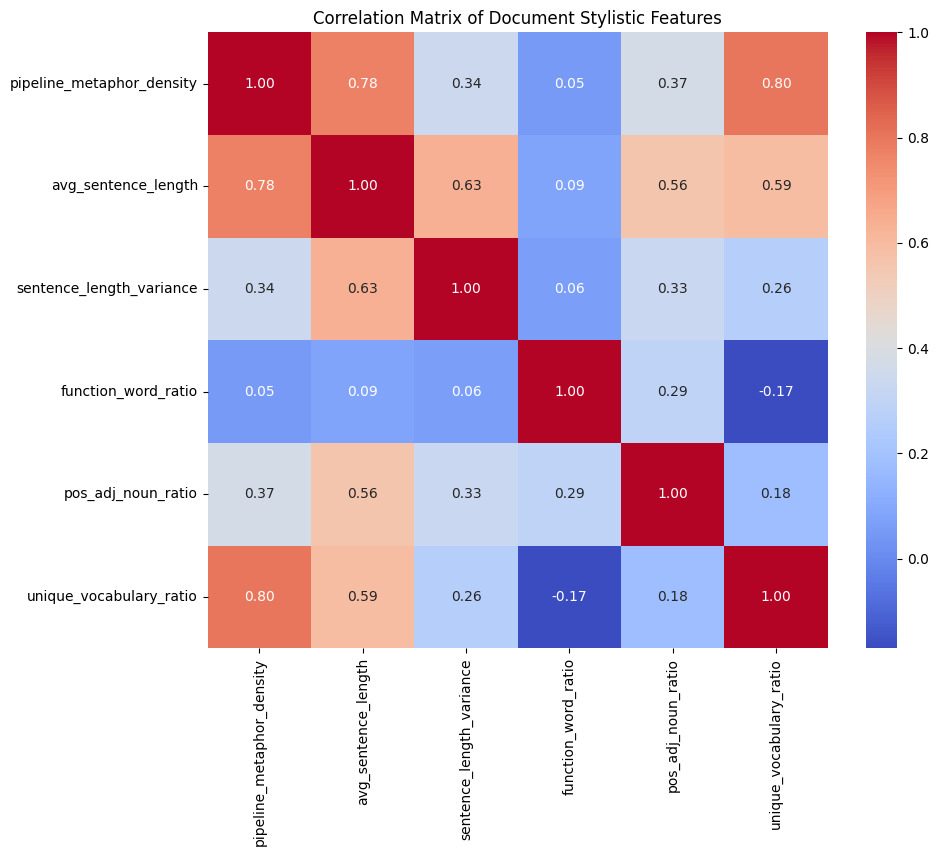

In [39]:
# plot correlation matrix
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df_document_stylistics.drop(columns=['document_name']).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Document Stylistic Features')
plt.show()

In [44]:
# which column has the biggest variance
df_document_stylistics.drop(columns=['document_name']).var().sort_values(ascending=False)

,0
sentence_length_variance,14078.544565
avg_sentence_length,77.160468
unique_vocabulary_ratio,0.020329
pos_adj_noun_ratio,0.012339
pipeline_metaphor_density,0.002146
function_word_ratio,0.001961


## Extract All Metaphor Tokens (corpus-wide)

In [ ]:
from collections import defaultdict

# Run pipeline on ALL of df_vuamc (not just test_df)
# to collect enough metaphor tokens for clustering

print("Extracting metaphor tokens from VUAMC...")
corpus_meta_tokens = []   # flat list of (word, sentence, doc)

for _, row in df_vuamc.iterrows():
    sent_text = ' '.join(row['words'])

    # Step 1: Sentence filter
    scores    = sent_pipe(sent_text) # FIX: Removed [0] here
    meta_prob = next((s['score'] for s in scores if s['label'] == 'LABEL_1'), 0.0)

    if meta_prob > 0.5:
        # Step 2: Token extraction
        entities = token_pipe(sent_text)
        for e in entities:
            if e['entity_group'] == 'LABEL_1': # FIX: Changed 'METAPHOR' to 'LABEL_1'
                word = e['word'].replace('▁', '').strip()
                if word and len(word) > 1:
                    corpus_meta_tokens.append({
                        'word':     word,
                        'sentence': sent_text,
                        'doc':      row['document_name']
                    })

df_tokens = pd.DataFrame(corpus_meta_tokens)
print(f"Total metaphor tokens collected: {len(df_tokens)}")
print(f"Unique words: {df_tokens['word'].nunique()}")
print(df_tokens['word'].value_counts().head(20))

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_metaphor(word):
    token = word_tokenize(word.lower())[0]  # Simple tokenization
    if len(token) < 2 or token in stop_words or token.isdigit():
        return None
    return lemmatizer.lemmatize(token)

# Apply to your dftokens or corpusmetatokens
df_tokens['clean_word'] = df_tokens['word'].apply(preprocess_metaphor)
df_tokens_clean = df_tokens.dropna(subset=['clean_word']).drop_duplicates('clean_word')
print('Clean unique metaphors:', len(df_tokens_clean))
print(df_tokens_clean['clean_word'].value_counts().head(10))


In [ ]:
df_tokens_clean.head()

In [ ]:
# create a list of metaphors from clean_word
clean_metaphors = df_tokens_clean['clean_word'].tolist()

In [ ]:
# Embed word IN SENTENCE CONTEXT — much better than bare word
# "break" in "break the ice" ≠ "break" in "break a leg"

from sentence_transformers import SentenceTransformer

print("Loading SentenceTransformer model...")

embedder = SentenceTransformer('all-MiniLM-L6-v2') # or any other suitable model

print("Embedding tokens in context...")
context_texts = [
    f"{row['word']} [SEP] {row['sentence'][:100]}"
    for _, row in df_tokens_clean.iterrows()
]
embs = embedder.encode(context_texts, show_progress_bar=True, batch_size=64)
print(f"Embeddings shape: {embs.shape}")  # (n_tokens, 384)


In [ ]:
import umap  # pip install umap-learn

# UMAP reduces 384 → 10 dims (preserves local structure better than PCA)
reducer = umap.UMAP(n_components=10, random_state=42, n_neighbors=15, min_dist=0.1)
embs_reduced = reducer.fit_transform(embs)
print("Reduced shape:", embs_reduced.shape)


In [ ]:
import os
from google.colab import userdata

# Retrieve the API key from Colab secrets
OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')

# Set the API key as an environment variable
os.environ['OPENAI_API_KEY'] = OPENAI_API_KEY

print("OpenAI API key loaded and set as environment variable.")

In [ ]:
import os

# Install huggingface_hub if not already installed
try:
    import huggingface_hub
except ImportError:
    !pip install huggingface_hub
    import huggingface_hub

from huggingface_hub import notebook_login

# Log in to Hugging Face
notebook_login()

In [ ]:
pip install -U bitsandbytes>=0.46.1

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import torch
import json
import gc

# 2B param: Gemma-2B-it (instruct-tuned, fits <4GB)
model_name = "google/gemma-2-2b-it"
bnb = BitsAndBytesConfig(load_in_4bit=True)  # Quantize to fit
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name, quantization_config=bnb, device_map="auto")

def tiny_llm_cluster(metaphors, max_tokens=50):  # Short list first
    text = "\n".join(metaphors[:50])  # Start small
    prompt = f"[INST] Cluster these metaphors into natural types. JSON only: {{'clusters':[{{\"type\":\"NAME\",\"tokens\":[\"w1\"]}}]}} \nTokens: {text} [/INST]"

    inputs = tokenizer(prompt, return_tensors="pt")
    with torch.no_grad():  # Save mem
        outputs = model.generate(**inputs, max_new_tokens=500, temperature=0.1, do_sample=True)
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Parse JSON
    try:
        start = response.find('{')
        return json.loads(response[start:])
    except:
        return {"error": "Parse fail—shorten list"}

clusters = tiny_llm_cluster(clean_metaphors.tolist())
print(clusters)
gc.collect()  # Free mem
torch.cuda.empty_cache()


In [ ]:
import hdbscan  # pip install hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=20,   # Min tokens per group (tune: 10-50)
    min_samples=5,          # Noise sensitivity (lower = more clusters)
    metric='euclidean'
)
cluster_ids = clusterer.fit_predict(embs_reduced)

n_clusters  = len(set(cluster_ids)) - (1 if -1 in cluster_ids else 0)
n_noise     = (cluster_ids == -1).sum()
print(f"Found {n_clusters} natural clusters")
print(f"Noise tokens (unassigned): {n_noise} ({n_noise/len(cluster_ids):.1%})")

df_tokens_clean['cluster'] = cluster_ids  # -1 = noise/unassigned


In [ ]:
# Top words per cluster (by frequency)
print("\n=== AUTO-DISCOVERED CLUSTERS ===")
for c in sorted(set(cluster_ids)):
    if c == -1:
        continue
    mask   = cluster_ids == c
    words  = df_tokens_clean[mask]['word'].tolist()
    top    = Counter(words).most_common(10)
    print(f"\nCluster {c:>3} ({mask.sum():>4} tokens): {[w for w,_ in top]}")


In [ ]:
# Auto-name each cluster using an LLM
# (skip if no API key — label manually instead)
import openai  # or use a free HuggingFace model

def auto_label_cluster(words_list, model="gpt-4o-mini"):
    """Ask LLM to name the metaphor category from example words"""
    sample = ', '.join(words_list[:20])
    prompt = f"""These words appear as metaphors in English text: {sample}

What single short category label (2-3 words max) best describes what these metaphors have in common?
Examples of good labels: 'animal behavior', 'physical force', 'color states', 'natural phenomena'
Reply with ONLY the label, nothing else."""

    response = openai.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}]
    )
    return response.choices[0].message.content.strip()

# Build CLUSTER_NAMES automatically
CLUSTER_NAMES = {}
for c in sorted(set(cluster_ids)):
    if c == -1:
        CLUSTER_NAMES[-1] = 'noise'
        continue
    mask  = cluster_ids == c
    words = df_tokens[mask]['word'].tolist()
    top_words = [w for w, _ in Counter(words).most_common(20)]

    # Option A: Auto-label (needs API key)
    # CLUSTER_NAMES[c] = auto_label_cluster(top_words)

    # Option B: Print and label manually (free)
    print(f"Cluster {c}: {top_words[:10]}")
    CLUSTER_NAMES[c] = f"cluster_{c}"  # Replace manually after inspection

print("\nCluster names:", CLUSTER_NAMES)


In [ ]:
# Run HDBSCAN with different min_cluster_size → see how many groups emerge
print(f"{'min_size':>10} {'n_clusters':>12} {'noise%':>8}")
print("-" * 32)
for min_size in [5, 10, 15, 20, 30, 50, 100]:
    hdb = hdbscan.HDBSCAN(min_cluster_size=min_size, min_samples=5)
    lbls = hdb.fit_predict(embs_reduced)
    n_c = len(set(lbls)) - (1 if -1 in lbls else 0)
    n_n = (lbls == -1).sum() / len(lbls)
    print(f"{min_size:>10} {n_c:>12} {n_n:>8.1%}")


In [ ]:
# Instead of embedding every occurrence, embed each UNIQUE word once
# with its most representative context sentence

df_unique = (df_tokens
             .groupby('word')
             .agg(
                 count=('word', 'count'),
                 sentence=('sentence', 'first'),  # Most representative context
                 doc=('doc', 'first')
             )
             .reset_index()
             .query('count >= 2'))  # Drop hapax legomena (appear only once)

print(f"Unique words (freq ≥ 2): {len(df_unique)}")
print(f"Dropped hapax legomena: {df_tokens['word'].nunique() - len(df_unique)}")
print(f"Top 20 most frequent:\n{df_unique.nlargest(20, 'count')[['word','count']]}")


In [ ]:
# Visualize raw embeddings in 2D BEFORE clustering
reducer_2d = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
coords_2d = reducer_2d.fit_transform(embs_unique)

plt.figure(figsize=(10, 7))
plt.scatter(coords_2d[:, 0], coords_2d[:, 1], s=5, alpha=0.4)

# Label top 30 most frequent words
top30_idx = df_unique.nlargest(30, 'count').index
for idx in top30_idx:
    plt.annotate(df_unique.loc[idx, 'word'],
                 (coords_2d[idx, 0], coords_2d[idx, 1]),
                 fontsize=7, alpha=0.8)

plt.title('UMAP 2D of Unique Metaphor Words')
plt.savefig('umap_2d.png', dpi=150); plt.show()


In [ ]:
import nltk
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

# Lemmatize before grouping: "running"→"run", "broken"→"break"
df_tokens['word_lemma'] = df_tokens['word'].str.lower().apply(
    lambda w: lemmatizer.lemmatize(w, pos='v')  # Try verb first
)

# Re-group by lemma instead of raw word
df_unique_lemma = (df_tokens
    .groupby('word_lemma')
    .agg(count=('word_lemma','count'), sentence=('sentence','first'))
    .reset_index()
    .query('count >= 3'))

print(f"Unique lemmas (freq ≥ 3): {len(df_unique_lemma)}")


In [ ]:
# Re-embed the 433 lemmas in context
context_texts_lemma = [
    f"{row['word_lemma']} [SEP] {row['sentence'][:100]}"
    for _, row in df_unique_lemma.iterrows()
]

print(f"Embedding {len(context_texts_lemma)} lemmas...")
embs_lemma = embedder.encode(context_texts_lemma, show_progress_bar=True, batch_size=64)
print(f"Shape: {embs_lemma.shape}")  # (433, 384)

# UMAP reduce
import umap
reducer = umap.UMAP(n_components=10, random_state=42, n_neighbors=15, min_dist=0.1)
embs_reduced = reducer.fit_transform(embs_lemma)
print(f"Reduced: {embs_reduced.shape}")  # (433, 10)

# Tune HDBSCAN
print(f"\n{'min_size':>10} {'n_clusters':>12} {'noise%':>8} {'avg_size':>10}")
print("-" * 44)
for min_size in [5, 8, 10, 12, 15, 20, 25, 30]:
    hdb = hdbscan.HDBSCAN(min_cluster_size=min_size, min_samples=3, metric='euclidean')
    lbls = hdb.fit_predict(embs_reduced)
    n_c  = len(set(lbls)) - (1 if -1 in lbls else 0)
    n_n  = (lbls == -1).sum() / len(lbls)
    avg  = (lbls != -1).sum() / n_c if n_c > 0 else 0
    print(f"{min_size:>10} {n_c:>12} {n_n:>8.1%} {avg:>10.1f}")


In [ ]:
# ← SET THIS after reading tuning table above
BEST_MIN_SIZE = 15

final_clusterer = hdbscan.HDBSCAN(
    min_cluster_size=BEST_MIN_SIZE,
    min_samples=3,
    metric='euclidean'
)
final_labels = final_clusterer.fit_predict(embs_reduced)

df_unique_lemma['cluster'] = final_labels
n_clusters_final = len(set(final_labels)) - (1 if -1 in final_labels else 0)
print(f"Final: {n_clusters_final} clusters, "
      f"{(final_labels==-1).sum()} noise lemmas ({(final_labels==-1).mean():.1%})\n")

# Inspect each cluster → fill CLUSTER_NAMES manually below
CLUSTER_NAMES = {}
for c in sorted(set(final_labels)):
    if c == -1:
        CLUSTER_NAMES[-1] = 'noise'
        continue
    top = (df_unique_lemma[df_unique_lemma['cluster'] == c]
           .nlargest(15, 'count')['word_lemma']
           .tolist())
    print(f"Cluster {c:>3}: {top}")
    CLUSTER_NAMES[c] = f'cluster_{c}'  # ← YOU replace with real name after seeing words

print("\n→ Fill CLUSTER_NAMES dict above, then continue to Cell 4 (train classifiers)")
